## Causal Inference in Time and Panels

13 — Difference-in-Differences <br>
14 — Panel Data and Fixed Effects <br>

15 — Synthetic Control 

In [3]:
import os
os.getcwd()
os.chdir('/Users/hiro/Documents/github/Causal_Inference/')

Want treatment effect on the treated after the intervention:

$$\hat{ATET} = E[Y_1(1)-Y_0(1)|D=1]$$
$Y_D(T)$ where $T$ indicates period and $D$ the potential outcome. But $Y_0(1)\mid D=1$ is counterfactual

$$\hat{ATET} = E[Y_1(1)-Y_0(1)|D=0]$$

Now think about the counterfactual. We think that the counterfactual at time 1 is the unit at time 0 + time trend

$$E[Y_0(1)|D=1] = E[Y_0(0)|D=1] + \left(E[Y_0(1)|D=0] - E[Y_0(0)|D=0]\right) $$

So we can rewrite the first with this:
$$\hat{ATET} = (E[Y(1)|D=1]- E[Y(1)|D=0]) - (E[Y(1)|D=0] - E[Y(1)|D=0]) $$

First term: difference in (treatment or not after) - (treatment or not before).

# Lecture 13: Difference-in-Differences

## Math

Let \(D\) denote treatment group status and \(T\) denote time:
- \(D=1\): treated group
- \(D=0\): control group
- \(T=0\): pre-treatment
- \(T=1\): post-treatment

Let \(Y_D(T)\) be the potential outcome for treatment status \(D\) at time \(T\). The target is the treatment effect on the treated after the intervention:
$$
ATET = E[Y_1(1)-Y_0(1)\mid D=1].
$$
The problem is that \(Y_0(1)\mid D=1\) is counterfactual. :contentReference[oaicite:0]{index=0}

A naive before-after comparison would be
$$
E[Y(1)\mid D=1]-E[Y(0)\mid D=1],
$$
but this assumes
$$
E[Y_0(1)\mid D=1] = E[Y_0(0)\mid D=1],
$$
that is, no time trend in the treated group absent treatment. This is usually too strong. :contentReference[oaicite:1]{index=1}

A naive treated-control comparison in the post period would be
$$
E[Y(1)\mid D=1]-E[Y(1)\mid D=0],
$$
but this assumes
$$
E[Y_0(1)\mid D=1] = E[Y_0(1)\mid D=0],
$$
that is, equal baseline levels across groups. This is also usually too strong. :contentReference[oaicite:2]{index=2}

Difference-in-differences replaces the missing counterfactual with
$$
E[Y_0(1)\mid D=1]
=
E[Y_0(0)\mid D=1]
+
\Big(E[Y_0(1)\mid D=0]-E[Y_0(0)\mid D=0]\Big).
$$
So the untreated outcome for the treated group after the intervention is approximated by:
- the treated group’s pre-treatment level,
- plus the control group’s time trend. :contentReference[oaicite:3]{index=3}

This requires the **parallel trends assumption**:
$$
E[Y_0(1)-Y_0(0)\mid D=1]
=
E[Y_0(1)-Y_0(0)\mid D=0].
$$
In words: absent treatment, treated and control would have changed by the same amount over time. :contentReference[oaicite:4]{index=4}

Plugging this into the target effect gives the DID estimator:
$$
ATET
=
\Big(E[Y(1)\mid D=1]-E[Y(1)\mid D=0]\Big)
-
\Big(E[Y(0)\mid D=1]-E[Y(0)\mid D=0]\Big).
$$
This is the difference between the post-treatment gap and the pre-treatment gap. :contentReference[oaicite:5]{index=5}

## Intuition

The control group tells us the background trend.  
We project that trend onto the treated group to construct its missing counterfactual.  
So DID removes:
- permanent level differences between groups, and
- common time shocks affecting both groups. :contentReference[oaicite:6]{index=6}

## Regression form

A standard DID regression is
$$
Y = \alpha + \beta D + \gamma T + \delta (D\times T) + u.
$$
Here:
- \(\beta\) captures baseline treated-control differences,
- \(\gamma\) captures common post-period changes,
- \(\delta\) is the DID estimator. :contentReference[oaicite:7]{index=7}

## One-line takeaway

> DID estimates the treatment effect by comparing how much the treated group changed relative to how much the control group changed, under parallel trends. :contentReference[oaicite:8]{index=8}

Non Parallel Trends

One obvious problem with Diff-in-Diff is failure to satisfy the parallel trend assumption. If the growth trend from the treated is different from the trend of the control, diff-in-diff will be biased. This is a common problem with non-random data, where the decision to treat a region is based on its potential to respond well to the treatment, or when the treatment is targeted at regions that are not performing very well. Take our marketing example. We decided to test billboards in Porto Alegre not in order to check the effect of billboards in general. The reason is simply because sales perform poorly there. Perhaps online marketing is not working there. In this case, it could be that the growth we would see in Porto Alegre without a billboard would be lower than the growth we observe in other cities. This would cause us to underestimate the effect of the billboard there.

One way to check if this is happening is to plot the trend using past periods. For example, let’s suppose POA had a small decreasing trend but Florianopolis was on a steep ascent. In this case, showing periods from before would reveal those trends and we would know Diff-in-Diff is not a reliable estimator. We will see how to solve this problem with synthetic control.

Difference-in-Differences estimate: 6.524557692307688
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    171.6423      2.363     72.625      0.000     167.009     176.276
poa         -125.6263      4.484    -28.015      0.000    -134.418    -116.835
jul           34.5232      3.036     11.372      0.000      28.571      40.475
poa:jul        6.5246      5.729      1.139      0.255      -4.706      17.755


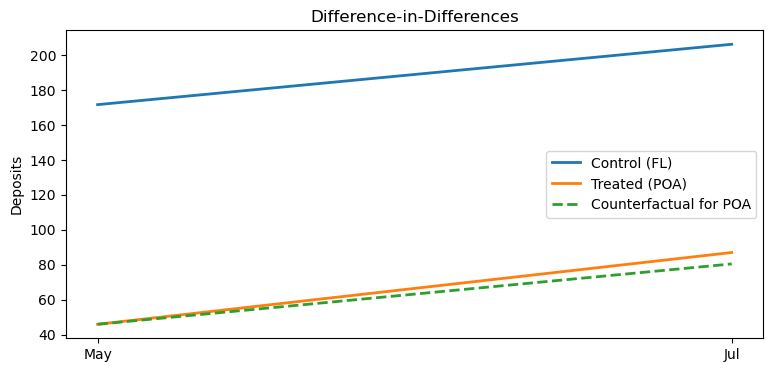

In [4]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

# Load data: poa=treated city, jul=post period, deposits=outcome
data = pd.read_csv("./data/billboard_impact.csv")

# Cell means
poa_before = data.query("poa == 1 and jul == 0")["deposits"].mean()
poa_after  = data.query("poa == 1 and jul == 1")["deposits"].mean()
fl_before  = data.query("poa == 0 and jul == 0")["deposits"].mean()
fl_after   = data.query("poa == 0 and jul == 1")["deposits"].mean()

# DID by hand
did = (poa_after - poa_before) - (fl_after - fl_before)
print("Difference-in-Differences estimate:", did)

# Same DID via regression: coefficient on poa:jul
did_reg = smf.ols("deposits ~ poa + jul + poa:jul", data=data).fit()
print(did_reg.summary().tables[1])

# Plot treated, control, and treated counterfactual
plt.figure(figsize=(9, 4))
plt.plot(["May", "Jul"], [fl_before, fl_after], label="Control (FL)", lw=2)
plt.plot(["May", "Jul"], [poa_before, poa_after], label="Treated (POA)", lw=2)
plt.plot(
    ["May", "Jul"],
    [poa_before, poa_before + (fl_after - fl_before)],
    label="Counterfactual for POA",
    lw=2,
    ls="--"
)

plt.ylabel("Deposits")
plt.title("Difference-in-Differences")
plt.legend()
plt.show()

# Lecture 14: Panel Data and Fixed Effects

## Math + intuition

Panel data means we observe the same unit \(i\) over multiple periods \(t\).  
The fixed-effects idea is to use **within-unit variation over time** to control for everything about the unit that does not change over time. :contentReference[oaicite:0]{index=0}

Start from
$$
Y_{it} = \beta X_{it} + \gamma U_i + e_{it},
$$
where:
- \(Y_{it}\): outcome for unit \(i\) at time \(t\)
- \(X_{it}\): time-varying regressors
- \(U_i\): unobserved, unit-specific, **time-invariant** factors
- \(e_{it}\): idiosyncratic error. :contentReference[oaicite:1]{index=1}

The key problem is that \(U_i\) may be correlated with \(X_{it}\).  
Example: beauty, ability, personality, or family background may affect both marriage and wages, but may be hard to measure. Fixed effects handle this **if those confounders are constant over time**. :contentReference[oaicite:2]{index=2}

The trick is to demean each variable within unit:
$$
\ddot{Y}_{it} = Y_{it} - \bar Y_i,
\qquad
\ddot{X}_{it} = X_{it} - \bar X_i.
$$
Then subtract the unit mean equation from the original equation:
$$
Y_{it} - \bar Y_i
=
\beta (X_{it} - \bar X_i) + \gamma(U_i-\bar U_i) + (e_{it}-\bar e_i).
$$
Because \(U_i\) is constant over time,
$$
U_i=\bar U_i,
$$
so it disappears:
$$
\ddot{Y}_{it} = \beta \ddot{X}_{it} + \ddot e_{it}.
$$
This is the fixed-effects / within estimator. :contentReference[oaicite:3]{index=3}

### Main intuition

Fixed effects compare each unit **to itself over time**.  
So the identifying variation is not “married vs unmarried people,” but rather “what happens to the same person when marital status changes?” :contentReference[oaicite:4]{index=4}

### Very important limitation

Any variable that is constant within unit over time also vanishes after demeaning, so it cannot be estimated separately in a fixed-effects regression. In the chapter’s wage panel example, variables like `black`, `hisp`, and `educ` are time-invariant and therefore drop out. :contentReference[oaicite:5]{index=5}

### One-line takeaway

> Fixed effects remove all unobserved confounders that are constant over time by using only within-unit changes. :contentReference[oaicite:6]{index=6}

In [5]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import statsmodels.formula.api as smf
from linearmodels.datasets import wage_panel

# Load panel data: same individuals observed over multiple years
data = wage_panel.load()

# Outcome, treatment, and time-varying controls
Y = "lwage"
X = ["married", "expersq", "union", "hours"]

# Compute each individual's time average
mean_data = data.groupby("nr")[X + [Y]].mean()

# Demean: subtract each person's average from each yearly observation
demeaned_data = (
    data
    .set_index("nr")[X + [Y]]
    - mean_data
).reset_index()

# Fixed-effects regression = OLS on demeaned data
fe_model = smf.ols(f"{Y} ~ {' + '.join(X)}", data=demeaned_data).fit()
print(fe_model.summary().tables[1])

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -7.318e-19      0.005  -1.44e-16      1.000      -0.010       0.010
married        0.1147      0.017      6.756      0.000       0.081       0.148
expersq        0.0040      0.000     21.958      0.000       0.004       0.004
union          0.0784      0.018      4.261      0.000       0.042       0.115
hours       -8.46e-05   1.25e-05     -6.744      0.000      -0.000      -6e-05


# Lecture 15: Synthetic Control

## Math + intuition

Suppose unit \(1\) is treated after period \(T_0\), and units \(j=2,\dots,J+1\) are untreated donors.  
For each unit \(j\) and time \(t\), let \(Y_{jt}\) be the observed outcome. The treatment effect for the treated unit at time \(t>T_0\) is
$$
\tau_{1t} = Y^I_{1t} - Y^N_{1t},
$$
where:
- \(Y^I_{1t}\): treated unit's observed outcome under intervention
- \(Y^N_{1t}\): treated unit's counterfactual outcome without intervention. :contentReference[oaicite:0]{index=0}

Synthetic control estimates the missing counterfactual as a weighted average of untreated units:
$$
\hat Y^N_{1t} = \sum_{j=2}^{J+1} w_j Y_{jt}.
$$
The weights define a **synthetic untreated version** of the treated unit. :contentReference[oaicite:1]{index=1}

The weights are chosen to make the synthetic unit look as similar as possible to the treated unit **before treatment**. In the chapter’s formalization, they solve
$$
\min_W \left\| X_1 - X_0 W \right\|
=
\left(
\sum_{h=1}^k
v_h
\left(
X_{h1} - \sum_{j=2}^{J+1} w_j X_{hj}
\right)^2
\right)^{1/2}
$$
subject to
$$
w_j \ge 0
\quad\text{and}\quad
\sum_{j=2}^{J+1} w_j = 1.
$$
So the synthetic control is a **convex combination** of donor units. :contentReference[oaicite:2]{index=2}

### Main intuition

Synthetic control is like “regression flipped sideways”:
- in usual regression, variables are columns and observations are rows;
- in synthetic control, **donor units act like regressors** and time periods act like observations. :contentReference[oaicite:3]{index=3}

The method uses the **pre-treatment path** of the treated unit to learn donor weights, then projects those weights into the post-treatment period.  
The estimated effect is the post-treatment gap
$$
\hat\tau_{1t} = Y_{1t} - \hat Y^N_{1t}.
$$
If the treated and synthetic units track each other well before treatment, then a post-treatment divergence is evidence of an effect. :contentReference[oaicite:4]{index=4}

### Why the constraints matter

The chapter emphasizes **don’t extrapolate**:
- weights must be nonnegative,
- weights must sum to one.

So the synthetic control stays inside the support of the donor pool instead of inventing impossible combinations. This usually gives a smoother, more credible counterfactual than unconstrained OLS. :contentReference[oaicite:5]{index=5}

### Inference idea

A common check is **placebo / permutation inference**:
- pretend each untreated unit was treated,
- build a synthetic control for it,
- compare its post-treatment gap with the treated unit’s gap.

Also remove placebo units with very poor pre-treatment fit, often using pre-treatment MSE:
$$
MSE = \frac{1}{N}\sum_t \left(Y_t - \hat Y^{Synth}_t\right)^2.
$$
If the treated unit’s post-treatment gap is unusually large relative to placebo gaps, that supports a treatment effect. :contentReference[oaicite:6]{index=6}

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fmin_slsqp

# Load state-year panel
cigar = (
    pd.read_csv("./data/smoking.csv")
    .drop(columns=["lnincome", "beer", "age15to24"])
)

# Loss: make synthetic control close to treated unit in pre-treatment periods
def loss_w(W, X, y):
    return np.sqrt(np.mean((y - X.dot(W)) ** 2))

# Constrained weights:
# - nonnegative
# - sum to 1
def get_w(X, y):
    w_start = [1 / X.shape[1]] * X.shape[1]
    return fmin_slsqp(
        lambda w: loss_w(w, X, y),
        np.array(w_start),
        f_eqcons=lambda w: np.sum(w) - 1,
        bounds=[(0.0, 1.0)] * len(w_start),
        disp=False
    )

# Use only pre-treatment data to learn donor weights
features = ["cigsale", "retprice"]

inverted = (
    cigar.query("~after_treatment")
    .pivot(index="state", columns="year")[features]
    .T
)

# California is the treated unit in this dataset (state == 3)
treated_state = 3

y = inverted[treated_state].values
X = inverted.drop(columns=treated_state).values

weights = get_w(X, y)

# Build synthetic California using donor states and the learned weights
calif_synth = (
    cigar.query("~california")
    .pivot(index="year", columns="state")["cigsale"]
    .values.dot(weights)
)

calif = cigar.query("california").copy()

# Plot treated vs synthetic
plt.figure(figsize=(10, 5))
plt.plot(calif["year"], calif["cigsale"], label="California")
plt.plot(calif["year"], calif_synth, label="Synthetic Control")
plt.vlines(x=1988, ymin=40, ymax=140, linestyle=":", lw=2, label="Proposition 99")
plt.ylabel("Per-capita cigarette sales")
plt.legend()
plt.show()

# Estimated treatment effect = observed - synthetic
effect = calif["cigsale"].values - calif_synth

plt.figure(figsize=(10, 5))
plt.plot(calif["year"], effect, label="California - Synthetic")
plt.vlines(x=1988, ymin=-30, ymax=10, linestyle=":", lw=2, label="Proposition 99")
plt.hlines(y=0, xmin=1970, xmax=2000, lw=2)
plt.ylabel("Gap in cigarette sales")
plt.legend()
plt.show()

# Optional: placebo synthetic controls for inference
def synthetic_control(state, data):
    features = ["cigsale", "retprice"]

    inverted = (
        data.query("~after_treatment")
        .pivot(index="state", columns="year")[features]
        .T
    )

    y = inverted[state].values
    X = inverted.drop(columns=state).values

    weights = get_w(X, y)

    synthetic = (
        data.query(f"state != {state}")
        .pivot(index="year", columns="state")["cigsale"]
        .values.dot(weights)
    )

    return (
        data.query(f"state == {state}")
        .assign(synthetic=synthetic)
    )

synthetic_states = [synthetic_control(s, cigar) for s in cigar["state"].unique()]

# Pre-treatment fit diagnostic
def pre_treatment_error(df):
    err = df.query("~after_treatment")["cigsale"] - df.query("~after_treatment")["synthetic"]
    return np.mean(err ** 2)

# Plot placebo gaps, dropping poorly fit units
plt.figure(figsize=(12, 6))
for state_df in synthetic_states:
    if pre_treatment_error(state_df) < 80:
        plt.plot(
            state_df["year"],
            state_df["cigsale"] - state_df["synthetic"],
            color="C5",
            alpha=0.4
        )

plt.plot(calif["year"], effect, label="California")
plt.vlines(x=1988, ymin=-50, ymax=120, linestyle=":", lw=2, label="Proposition 99")
plt.hlines(y=0, xmin=1970, xmax=2000, lw=2)
plt.ylabel("Gap in cigarette sales")
plt.legend()
plt.show()